Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Loading the dataset

In [ ]:
df = pd.read_csv("advertising.csv")
df.columns = ["TV", "Radio", "Newspaper", "Sales"]

Basic data exploration

In [ ]:
print(df.shape)

(200, 4)


In [ ]:
print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [ ]:
print(df.describe().round(2))

           TV   Radio  Newspaper   Sales
count  200.00  200.00     200.00  200.00
mean   147.04   23.26      30.55   15.13
std     85.85   14.85      21.78    5.28
min      0.70    0.00       0.30    1.60
25%     74.38    9.98      12.75   11.00
50%    149.75   22.90      25.75   16.00
75%    218.82   36.52      45.10   19.05
max    296.40   49.60     114.00   27.00


In [ ]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


Feature Engineering and Data visualization

In [ ]:
df["Total_Ad_Spend"] = df["TV"] + df["Radio"] + df["Newspaper"]

Sales made vs Total amount spent on advertising

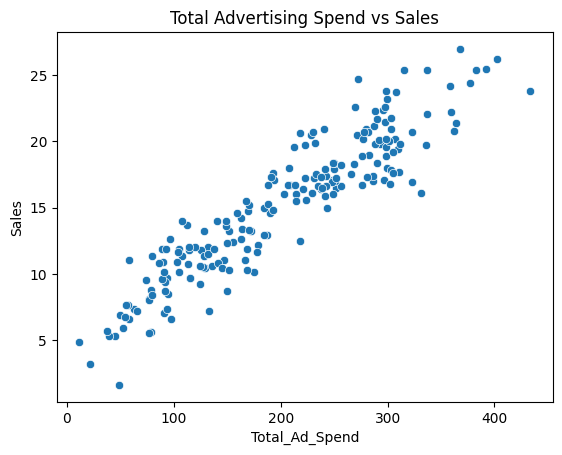

In [ ]:
sns.scatterplot(x="Total_Ad_Spend", y="Sales", data=df)
plt.title("Total Advertising Spend vs Sales")
plt.show()

Average Amount spent on Advertising in each medium

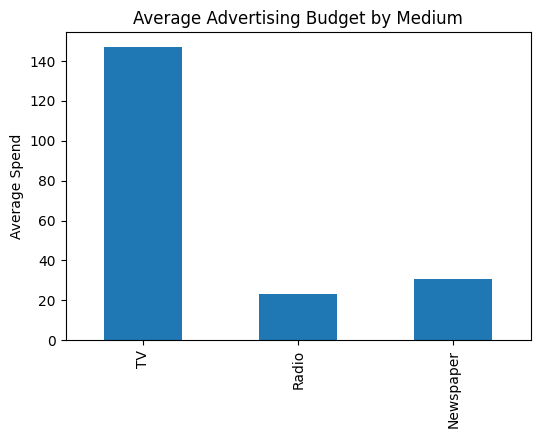

In [ ]:
avg_spend = df[["TV","Radio","Newspaper"]].mean()

plt.figure(figsize=(6,4))
avg_spend.plot(kind="bar")
plt.ylabel("Average Spend")
plt.title("Average Advertising Budget by Medium")
plt.show()

Sales Categories

In [ ]:
df["Sales_Category"] = pd.qcut(
    df["Sales"],
    q=3,
    labels=["Low","Medium","High"]
)

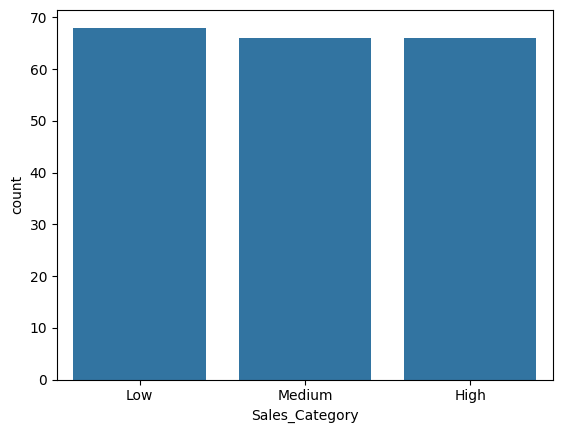

In [ ]:
sns.countplot(x="Sales_Category", data=df)
plt.show()

Advertising Efficiency

In [ ]:
df["Sales_Category_Encoded"] = df["Sales_Category"].map({"Low": 0, "Medium": 1, "High": 2})
print(df[["Sales", "Sales_Category", "Sales_Category_Encoded"]].head())

   Sales Sales_Category Sales_Category_Encoded
0   22.1           High                      2
1   10.4            Low                      0
2   12.0            Low                      0
3   16.5         Medium                      1
4   17.9           High                      2


In [ ]:
df["Efficiency"] = df["Sales"] / (df["TV"] + df["Radio"] + df["Newspaper"])

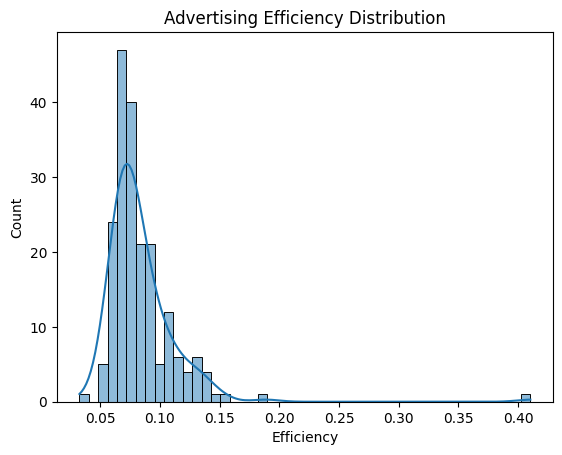

In [ ]:
sns.histplot(df["Efficiency"], kde=True)
plt.title("Advertising Efficiency Distribution")
plt.show()

Top Perfroming Campaigns

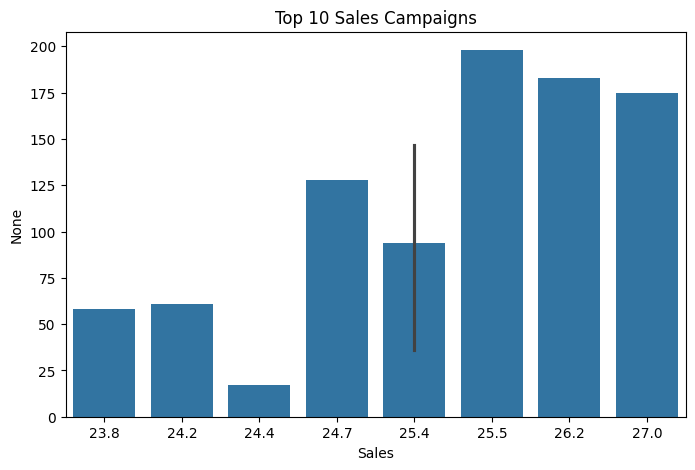

In [ ]:
top_campaigns = df.nlargest(10, "Sales")

plt.figure(figsize=(8,5))
sns.barplot(
    x=top_campaigns["Sales"],
    y=top_campaigns.index
)
plt.title("Top 10 Sales Campaigns")
plt.show()

Correlation Heatmap

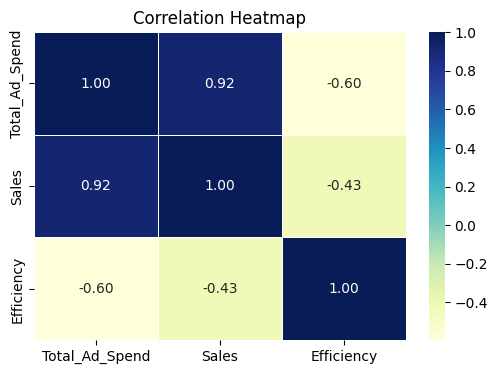

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    df[["Total_Ad_Spend", "Sales", "Efficiency"]].corr(),
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Splitting the data (Training and Testing)

In [ ]:
X = df[["TV", "Radio", "Newspaper", "Total_Ad_Spend", "Efficiency", "Sales_Category_Encoded"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 160
Testing samples  : 40


In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Scaling done.")

Scaling done.


Linear Regression

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)
lr_pred = lr_model.predict(X_test_sc)

print("Linear Regression")
print(f"  MAE  : {mean_absolute_error(y_test, lr_pred):.3f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, lr_pred)):.3f}")
print(f"  R²   : {r2_score(y_test, lr_pred):.3f}")

Linear Regression
  MAE  : 1.129
  RMSE : 1.436
  R²   : 0.933


Ridge Regression

In [ ]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_sc, y_train)
ridge_pred = ridge_model.predict(X_test_sc)

print("Ridge Regression")
print(f"  MAE  : {mean_absolute_error(y_test, ridge_pred):.3f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, ridge_pred)):.3f}")
print(f"  R²   : {r2_score(y_test, ridge_pred):.3f}")

Ridge Regression
  MAE  : 1.132
  RMSE : 1.439
  R²   : 0.933


Lasso Regression

In [ ]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_sc, y_train)
lasso_pred = lasso_model.predict(X_test_sc)

print("Lasso Regression")
print(f"  MAE  : {mean_absolute_error(y_test, lasso_pred):.3f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, lasso_pred)):.3f}")
print(f"  R²   : {r2_score(y_test, lasso_pred):.3f}")

Lasso Regression
  MAE  : 1.199
  RMSE : 1.513
  R²   : 0.926


Random Forest

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest")
print(f"  MAE  : {mean_absolute_error(y_test, rf_pred):.3f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, rf_pred)):.3f}")
print(f"  R²   : {r2_score(y_test, rf_pred):.3f}")

Random Forest
  MAE  : 0.888
  RMSE : 1.265
  R²   : 0.948


Gradient Boosting

In [ ]:
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting")
print(f"  MAE  : {mean_absolute_error(y_test, gb_pred):.3f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, gb_pred)):.3f}")
print(f"  R²   : {r2_score(y_test, gb_pred):.3f}")

Gradient Boosting
  MAE  : 0.877
  RMSE : 1.208
  R²   : 0.953


Compare all models

In [ ]:
results = {
    "Linear Regression" : {"MAE": mean_absolute_error(y_test, lr_pred),    "RMSE": np.sqrt(mean_squared_error(y_test, lr_pred)),    "R2": r2_score(y_test, lr_pred),    "pred": lr_pred},
    "Ridge Regression"  : {"MAE": mean_absolute_error(y_test, ridge_pred),  "RMSE": np.sqrt(mean_squared_error(y_test, ridge_pred)),  "R2": r2_score(y_test, ridge_pred),  "pred": ridge_pred},
    "Lasso Regression"  : {"MAE": mean_absolute_error(y_test, lasso_pred),  "RMSE": np.sqrt(mean_squared_error(y_test, lasso_pred)),  "R2": r2_score(y_test, lasso_pred),  "pred": lasso_pred},
    "Random Forest"     : {"MAE": mean_absolute_error(y_test, rf_pred),     "RMSE": np.sqrt(mean_squared_error(y_test, rf_pred)),     "R2": r2_score(y_test, rf_pred),     "pred": rf_pred},
    "Gradient Boosting" : {"MAE": mean_absolute_error(y_test, gb_pred),     "RMSE": np.sqrt(mean_squared_error(y_test, gb_pred)),     "R2": r2_score(y_test, gb_pred),     "pred": gb_pred},
}

print(f"{'Model':<25} {'MAE':>6}  {'RMSE':>6}  {'R2':>6}")
print("-" * 50)
for name, m in results.items():
    print(f"{name:<25} {m['MAE']:>6.3f}  {m['RMSE']:>6.3f}  {m['R2']:>6.3f}")

Model                        MAE    RMSE      R2
--------------------------------------------------
Linear Regression          1.129   1.436   0.933
Ridge Regression           1.132   1.439   0.933
Lasso Regression           1.199   1.513   0.926
Random Forest              0.888   1.265   0.948
Gradient Boosting          0.877   1.208   0.953


R² Bar Chart

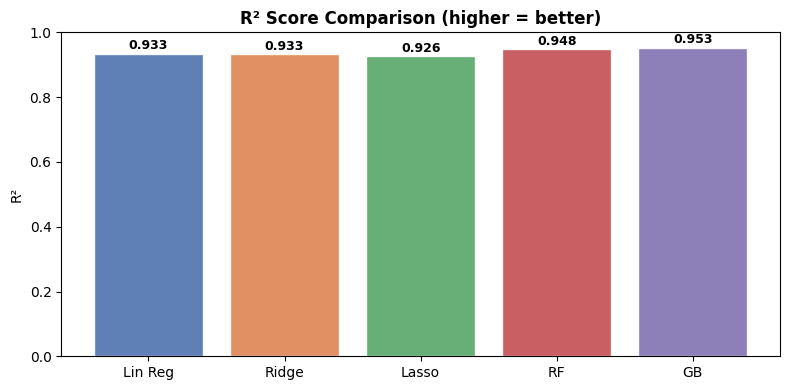

In [ ]:
names  = list(results.keys())
r2     = [results[n]["R2"] for n in names]
labels = ["Lin Reg", "Ridge", "Lasso", "RF", "GB"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, r2, color=colors, edgecolor="white", alpha=0.9)

for bar, val in zip(bars, r2):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.title("R² Score Comparison (higher = better)", fontweight="bold")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

RMSE Comparision

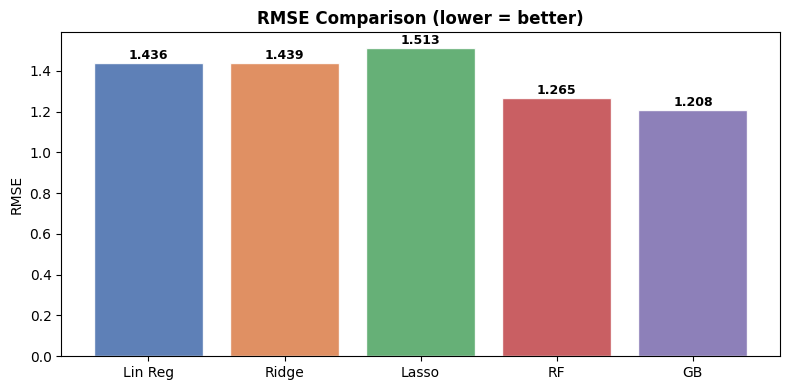

In [ ]:
rmse   = [results[n]["RMSE"] for n in names]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, rmse, color=colors, edgecolor="white", alpha=0.9)

for bar, val in zip(bars, rmse):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.title("RMSE Comparison (lower = better)", fontweight="bold")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

MAE Comparision

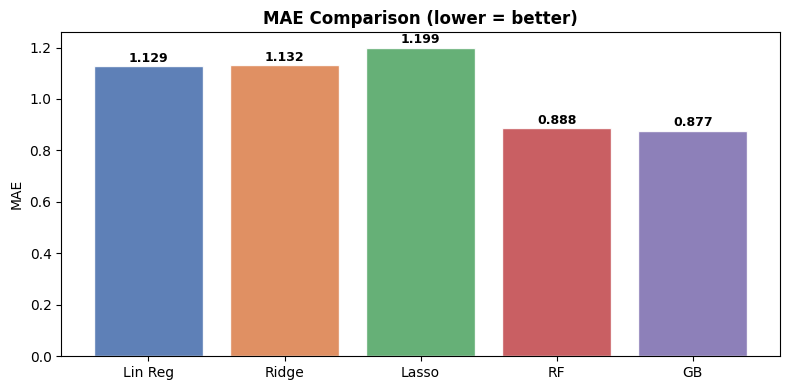

In [ ]:
mae = [results[n]["MAE"] for n in names]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, mae, color=colors, edgecolor="white", alpha=0.9)

for bar, val in zip(bars, mae):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.title("MAE Comparison (lower = better)", fontweight="bold")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

Gradient Boosting (Predicted vs Actual)

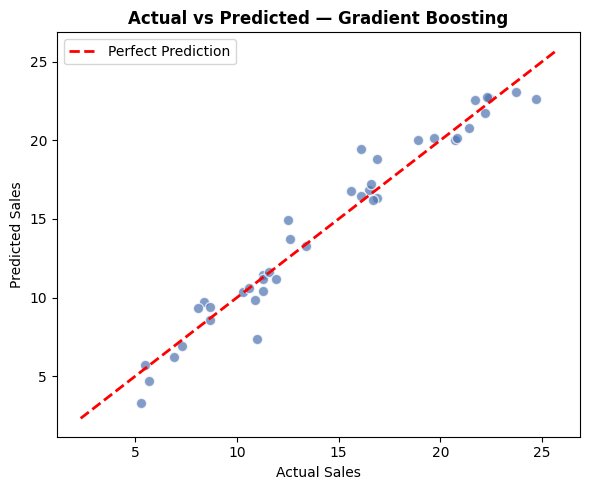

In [ ]:
gb_pred = results["Gradient Boosting"]["pred"]

plt.figure(figsize=(6, 5))
plt.scatter(y_test, gb_pred, color="#4C72B0", alpha=0.7, edgecolors="white", s=55)

lims = [min(y_test.min(), gb_pred.min()) - 1,
        max(y_test.max(), gb_pred.max()) + 1]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted — Gradient Boosting", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

Residual Scatterplot

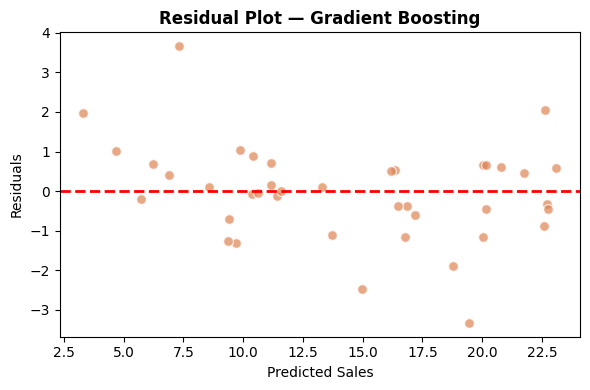

In [ ]:
residuals = y_test.values - gb_pred

plt.figure(figsize=(6, 4))
plt.scatter(gb_pred, residuals, color="#DD8452", alpha=0.7, edgecolors="white", s=50)
plt.axhline(0, color="red", linewidth=2, linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot — Gradient Boosting", fontweight="bold")
plt.tight_layout()
plt.show()

Feature Importance Values

In [ ]:
importances = gb_model.feature_importances_
feat_names  = ["TV", "Radio", "Newspaper", "Total_Ad_Spend", "Efficiency"]

for name, score in zip(feat_names, importances):
    print(f"  {name:<20} {score:.4f}")

  TV                   0.1500
  Radio                0.0353
  Newspaper            0.0019
  Total_Ad_Spend       0.7245
  Efficiency           0.0146


Prediction Function

In [ ]:
def predict_sales(tv, radio, newspaper):
    total_spend = tv + radio + newspaper
    efficiency  = 0
    sales_cat   = 1  # 0=Low, 1=Medium, 2=High — default to Medium
    X_new = pd.DataFrame(
        [[tv, radio, newspaper, total_spend, efficiency, sales_cat]],
        columns=["TV", "Radio", "Newspaper", "Total_Ad_Spend", "Efficiency", "Sales_Category_Encoded"]
    )
    prediction = gb_model.predict(X_new)[0]
    return round(prediction, 2)

Testing the Prediction

In [ ]:
print(f"TV=200, Radio=40,  Newspaper=30  →  Predicted Sales: {predict_sales(200, 40, 30)}")
print(f"TV=50,  Radio=10,  Newspaper=5   →  Predicted Sales: {predict_sales(50, 10, 5)}")
print(f"TV=150, Radio=25,  Newspaper=20  →  Predicted Sales: {predict_sales(150, 25, 20)}")
print(f"TV=300, Radio=50,  Newspaper=60  →  Predicted Sales: {predict_sales(300, 50, 60)}")

TV=200, Radio=40,  Newspaper=30  →  Predicted Sales: 17.87
TV=50,  Radio=10,  Newspaper=5   →  Predicted Sales: 8.76
TV=150, Radio=25,  Newspaper=20  →  Predicted Sales: 14.8
TV=300, Radio=50,  Newspaper=60  →  Predicted Sales: 25.0
